In [8]:
# Kaggle API setup
from google.colab import userdata
import os
os.environ['KAGGLE_USERNAME'] = 'missimtiaz'  # apna Kaggle username daalo
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
# EMNIST dataset download
!pip install kaggle -q
!kaggle datasets download -d crawford/emnist
!unzip -q emnist.zip

print("Dataset download complete!")
!ls

Dataset URL: https://www.kaggle.com/datasets/crawford/emnist
License(s): CC0-1.0
100% 1.24G/1.24G [00:17<00:00, 74.1MB/s]

Dataset download complete!
emnist-balanced-mapping.txt  emnist-bymerge-train.csv	 emnist-mnist-test.csv
emnist-balanced-test.csv     emnist-digits-mapping.txt	 emnist-mnist-train.csv
emnist-balanced-train.csv    emnist-digits-test.csv	 emnist_source_files
emnist-byclass-mapping.txt   emnist-digits-train.csv	 emnist.zip
emnist-byclass-test.csv      emnist-letters-mapping.txt  predictions.png
emnist-byclass-train.csv     emnist-letters-test.csv	 README.md
emnist-bymerge-mapping.txt   emnist-letters-train.csv	 sample_letters.png
emnist-bymerge-test.csv      emnist-mnist-mapping.txt	 training_history.png


Loading data...
Train shape: (88800, 785)
Test shape: (14800, 785)
X_train shape: (88800, 28, 28, 1)
Labels unique: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]


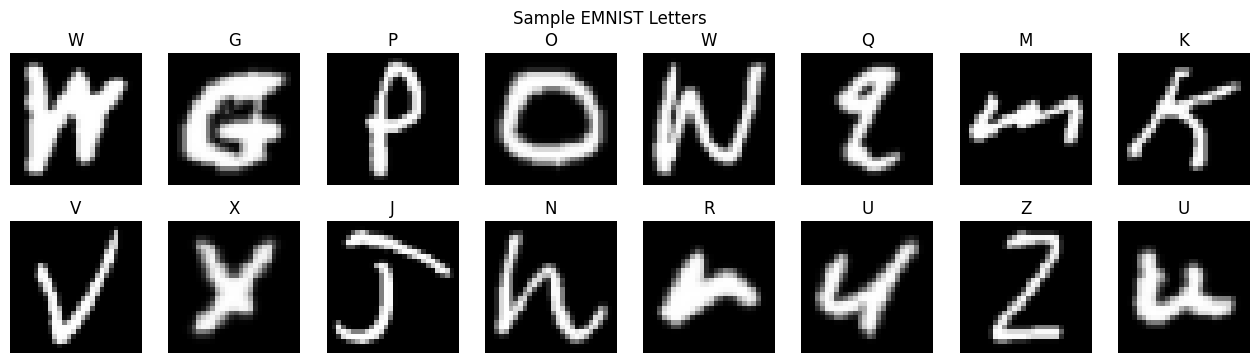

Data ready!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# data load karna
print("Loading data...")
train_df = pd.read_csv('emnist-letters-train.csv', header=None)
test_df = pd.read_csv('emnist-letters-test.csv', header=None)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# labels aur pixels alag karna
y_train = train_df.iloc[:, 0].values - 1  # 1-26 ko 0-25 mein convert karna
X_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values - 1
X_test = test_df.iloc[:, 1:].values

# normalize karna (0-255 ko 0-1 mein)
X_train = X_train / 255.0
X_test = X_test / 255.0

# CNN ke liye reshape karna (samples, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("X_train shape:", X_train.shape)
print("Labels unique:", np.unique(y_train))

# kuch sample images dekhna
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
letters = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28).T, cmap='gray')
    ax.set_title(letters[y_train[i]])
    ax.axis('off')
plt.suptitle("Sample EMNIST Letters")
plt.savefig("sample_letters.png")
plt.show()

print("Data ready!")

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# labels ko one-hot encode karna
y_train_cat = to_categorical(y_train, 26)
y_test_cat = to_categorical(y_test, 26)

# CNN model banana
model = Sequential([
    # pehli convolutional layer
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    # doosri convolutional layer
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # flatten karke dense layers mein daalna
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(26, activation='softmax')
])

model.summary()

# compile karna
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# train karna
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

print("Training complete!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,098 (887.10 KB)

 Trainable params: 227,098 (887.10 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 115ms/step - accuracy: 0.7438 - loss: 0.8382 - val_accuracy: 0.8874 - val_loss: 0.3508
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 111ms/step - accuracy: 0.8695 - loss: 0.4025 - val_accuracy: 0.9063 - val_loss: 0.2873
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 110ms/step - accuracy: 0.8935 - loss: 0.3259 - val_accuracy: 0.9211 - val_loss: 0.2539
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 119ms/step - accuracy: 0.9055 - loss: 0.2874 - val_accuracy: 0.9235 - val_loss: 0.2407
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 121ms/step - accuracy: 0.9124 - loss: 0.2608 - val_accuracy: 0.9271 - val_loss: 0.2306
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 114ms/step - accuracy: 0.9200 - loss: 0.2374 - val_accuracy: 0.9339 - val_loss: 0.2194
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - accuracy: 0.9250 - loss: 0.2212 - val_accuracy: 0.9322 - val_loss: 0.2197
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - accuracy: 0.9276 - loss: 0

Test Accuracy: 0.9220 (92.20%)


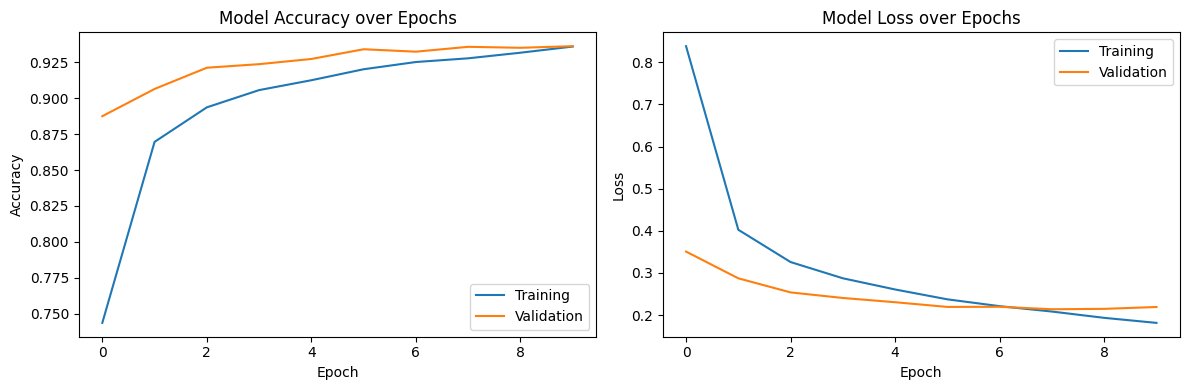

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


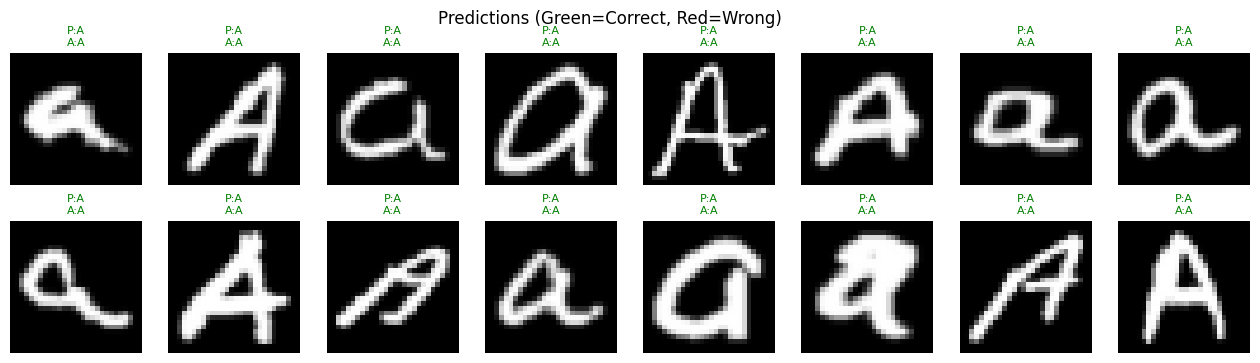

In [4]:
# test set pe evaluate karna
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# training history graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Training')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Training')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

# sample predictions dekhna
predictions = model.predict(X_test[:16])
predicted_labels = np.argmax(predictions, axis=1)
actual_labels = y_test[:16]
letters = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28).T, cmap='gray')
    color = 'green' if predicted_labels[i] == actual_labels[i] else 'red'
    ax.set_title(f"P:{letters[predicted_labels[i]]}\nA:{letters[actual_labels[i]]}",
                 color=color, fontsize=8)
    ax.axis('off')
plt.suptitle("Predictions (Green=Correct, Red=Wrong)")
plt.savefig('predictions.png')
plt.show()

In [7]:
from google.colab import userdata
import os

token = userdata.get('GITHUB_TOKEN')

# clean folder
os.makedirs('/content/repo_push', exist_ok=True)
os.chdir('/content/repo_push')

# fresh clone
!git clone https://{token}@github.com/Miss-Imtiaz/CodeAlpha_Handwritten-Character-Recognition.git
os.chdir('/content/repo_push/CodeAlpha_Handwritten-Character-Recognition')

# files copy karo
import shutil
for f in ['training_history.png', 'predictions.png', 'sample_letters.png']:
    try:
        shutil.copy(f'/content/{f}', '.')
        print(f"Copied: {f}")
    except:
        print(f"Not found: {f}")

!git add .
!git commit -m "Add training graphs and predictions"
!git push https://{token}@github.com/Miss-Imtiaz/CodeAlpha_Handwritten-Character-Recognition.git main
print("Done!")

Cloning into 'CodeAlpha_Handwritten-Character-Recognition'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 8 (delta 1), reused 4 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 95.88 KiB | 5.05 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Copied: training_history.png
Copied: predictions.png
Copied: sample_letters.png
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
Done!
